In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, expon
import pandas as pd
import seaborn as sns

Patient Arrival Generation

In [6]:
# SET THE SEED FOR REPRODUCIBILITY
np.random.seed(42)

# Parameters
T_MAX = 365.0

# types of Patients
acute = 1
intensive = 2
regular = 3

# arrival rate functions
def lambda_1(t):
    """Ward A arrival rate (Regular care)"""
    # np.where(condition, value_if_true, value_if_false)
    return np.where((0 < t) & (t < T_MAX), -(1/3650) * (t**2) + (1/10) * t, 0.0)

def lambda_2(t):
    """Ward B arrival rate (Intensive care)"""
    return 0.2 * lambda_1(t)

lambda_3_val = 6.0 

# Log-normal LOS parameters: (mu, sigma^2)
los_params = {
    'A': {'mu': np.log(4 * np.sqrt(2)), 'sigma': np.sqrt(np.log(2))}, 
    'B': {'mu': np.log(6 * np.sqrt(2)), 'sigma': np.sqrt(np.log(2))}, 
    'C': {'mu': np.log(5 * np.sqrt(2)), 'sigma': np.sqrt(np.log(2))}  
}

def generate_arrivals(lambda_func, t_max):
    """Generates arrival times using the Thinning (rejection) method."""
    # Find the maximum rate to use as the bounding envelope
    t_vals = np.linspace(0, t_max, 1000)
    lambda_max = max(lambda_func(t_vals)) # This will work perfectly now!
    
    arrivals = []
    t = 0.0
    while t < t_max:
        # Generate next potential arrival from homogeneous Poisson process
        u1 = np.random.uniform(0, 1)
        t += -np.log(u1) / lambda_max
        
        if t >= t_max:
            break
            
        # Accept/Reject step (evaluating a single float t here)
        u2 = np.random.uniform(0, 1)
        if u2 <= lambda_func(t) / lambda_max:
            arrivals.append(t)
            
    return np.array(arrivals)

# generate patient arrivals at each ward, check if it makes sense
arrivals_A = generate_arrivals(lambda_1, T_MAX)
arrivals_B = generate_arrivals(lambda_2, T_MAX)
arrivals_C = np.cumsum(np.random.exponential(1.0 / lambda_3_val, int(lambda_3_val * T_MAX * 1.2)))
arrivals_C = arrivals_C[arrivals_C < T_MAX]

print(f"Generated arrivals -> Ward A: {len(arrivals_A)}, Ward B: {len(arrivals_B)}, Ward C: {len(arrivals_C)}")


# Helper functions

def initialize_event_schedule():
    """Generates all initial patient arrival events using explicit task terminology."""
    arr_A = generate_arrivals(lambda_1, T_MAX)
    arr_B = generate_arrivals(lambda_2, T_MAX)

    # Ward C constant arrival stream
    arr_C = np.cumsum(np.random.exponential(1.0 / lambda_3_val, int(lambda_3_val * T_MAX * 1.5)))
    arr_C = arr_C[arr_C < T_MAX]
    
    # Event layout: [time, event_type, patient_type, ward_occupied]
    events = []
    for t in arr_A: events.append([t, 'arrival', 'regular', None])
    for t in arr_B: events.append([t, 'arrival', 'intensive', None])
    for t in arr_C: events.append([t, 'arrival', 'other', None])
    
    events.sort(key=lambda x: x[0])
    return events

def sample_los(ptype, use_exponential_los):
    """Calculates stay length depending on whether exponential or lognormal distributions are requested."""
    if use_exponential_los:
        # Maps regular -> 8, intensive -> 12, other -> 10
        mean_los = 8.0 if ptype == 'regular' else (12.0 if ptype == 'intensive' else 10.0)
        return np.random.exponential(mean_los)
    else:
        # Convert terms back to original dictionary configuration map
        old_key = 'A' if ptype == 'regular' else ('B' if ptype == 'intensive' else 'C')
        p = los_params[old_key]
        return np.random.lognormal(p['mu'], p['sigma'])


def handle_patient_arrival(current_time, p_type, current_occupancy, capacity, metrics, events, use_exponential_los):
    """
    Routes patients, handles intensive overflow, and logs arrivals, blockages, 
    relocations, AND explicit ward placement metrics.
    """
    metrics['arrivals_count'][p_type] += 1
    
    # Inline helper to handle successful admission mechanics
    def admit_patient(assigned_ward):
        current_occupancy[assigned_ward][p_type] += 1
        dep_time = current_time + sample_los(p_type, use_exponential_los)
        events.append([dep_time, 'departure', p_type, assigned_ward])
        
        # NEW: Explicitly count which patient type was admitted to which physical ward
        metrics['admitted_placement_counts'][assigned_ward][p_type] += 1

    # Calculate total active beds full right now
    total_beds_in_A = current_occupancy['A']['regular'] + current_occupancy['A']['intensive']
    total_beds_in_B = current_occupancy['B']['intensive']
    total_beds_in_C = current_occupancy['C']['other']

    # --- Routing Logic ---
    if p_type == 'regular':
        if total_beds_in_A < capacity['A']:
            admit_patient('A')
        else:
            metrics['blocked_on_arrival']['regular'] += 1
            metrics['relocated_count']['regular'] += 1

    elif p_type == 'intensive':
        if total_beds_in_B < capacity['B']:
            admit_patient('B')  # Intensive patient admitted to Ward B
        elif total_beds_in_A < capacity['A']:
            metrics['blocked_on_arrival']['intensive'] += 1  # Blocked from primary ward B
            admit_patient('A')                               # But admitted to overflow Ward A
        else:
            metrics['blocked_on_arrival']['intensive'] += 1
            metrics['relocated_count']['intensive'] += 1
            
    elif p_type == 'other':
        if total_beds_in_C < capacity['C']:
            admit_patient('C')
        else:
            metrics['blocked_on_arrival']['other'] += 1
            metrics['relocated_count']['other'] += 1


def simulate_hospital(beds_A, beds_B, beds_C, use_exponential_los=False):
    """
    Runs a single 365-day simulation tracking patient flow and 
    statistics strictly categorized by patient type and ward boundaries.
    """
    events = initialize_event_schedule()
    capacity = {'A': beds_A, 'B': beds_B, 'C': beds_C}
    
    # Track exactly which patient type is in which ward
    current_occupancy = {
        'A': {'regular': 0, 'intensive': 0},
        'B': {'intensive': 0},
        'C': {'other': 0}
    }
    
    # Performance metrics categorized strictly by PATIENT TYPE
    metrics = {
        'arrivals_count':     {'regular': 0, 'intensive': 0, 'other': 0},
        'blocked_on_arrival': {'regular': 0, 'intensive': 0, 'other': 0},
        'relocated_count':    {'regular': 0, 'intensive': 0, 'other': 0},
        
        # NEW TRACKER STRUCTURE: Tracks physical placement counts
        'admitted_placement_counts': {
            'A': {'regular': 0, 'intensive': 0},
            'B': {'intensive': 0},
            'C': {'other': 0}
        },
        
        'patient_days_in_system': {'regular': 0.0, 'intensive': 0.0, 'other': 0.0},
        'bed_days_occupied':  {'A': 0.0, 'B': 0.0, 'C': 0.0}
    }
    
    last_time = 0.0
    
    while len(events) > 0:
        events.sort(key=lambda x: x[0])
        current_time, event_type, p_type, ward_occupied = events.pop(0)
        
        if current_time > T_MAX:
            break
            
        dt = current_time - last_time
        
        # Accumulate Patient-Type Metrics and Ward Metrics
        active_regular = current_occupancy['A']['regular']
        active_intensive = current_occupancy['B']['intensive'] + current_occupancy['A']['intensive']
        active_other = current_occupancy['C']['other']
        
        metrics['patient_days_in_system']['regular'] += active_regular * dt
        metrics['patient_days_in_system']['intensive'] += active_intensive * dt
        metrics['patient_days_in_system']['other'] += active_other * dt
        
        # Total beds occupied physically by ward
        metrics['bed_days_occupied']['A'] += (current_occupancy['A']['regular'] + current_occupancy['A']['intensive']) * dt
        metrics['bed_days_occupied']['B'] += current_occupancy['B']['intensive'] * dt
        metrics['bed_days_occupied']['C'] += current_occupancy['C']['other'] * dt
        
        last_time = current_time
        
        # Process Chronological Event
        if event_type == 'departure':
            # Remove the specific patient type from the ward they were occupying
            current_occupancy[ward_occupied][p_type] -= 1
            
        elif event_type == 'arrival':
            handle_patient_arrival(
                current_time, p_type, current_occupancy, capacity, 
                metrics, events, use_exponential_los
            )
                    
    return metrics

Generated arrivals -> Ward A: 2206, Ward B: 417, Ward C: 2303


In [7]:
# Run it once to get initial metrics

initial_metrics = simulate_hospital(beds_A=20, beds_B=10, beds_C=45, use_exponential_los=True)
initial_metrics

{'arrivals_count': {'regular': 2210, 'intensive': 492, 'other': 2087},
 'blocked_on_arrival': {'regular': 1498, 'intensive': 247, 'other': 581},
 'relocated_count': {'regular': 1498, 'intensive': 182, 'other': 581},
 'admitted_placement_counts': {'A': {'regular': 712, 'intensive': 65},
  'B': {'intensive': 245},
  'C': {'other': 1506}},
 'patient_days_in_system': {'regular': np.float64(5849.672216448762),
  'intensive': np.float64(3711.027746932039),
  'other': np.float64(15380.004920084846)},
 'bed_days_occupied': {'A': np.float64(6618.53190037242),
  'B': np.float64(2942.168063008401),
  'C': np.float64(15380.004920084846)}}

In [8]:
def evaluate_hospital_performance(beds_A, beds_B, beds_C, replications=20, use_exponential=False):
    """
    Runs multiple independent hospital simulation replications to estimate 
    primary performance measures with statistical averages.
    """
    T_MAX = 365.0
    
    # Storage structures to accumulate data across all Monte Carlo runs
    history = {
        'arrivals': {'regular': [], 'intensive': [], 'other': []},
        'blocked':  {'regular': [], 'intensive': [], 'other': []},
        'relocated':{'regular': [], 'intensive': [], 'other': []},
        'utilization': {'A': [], 'B': [], 'C': []}
    }
    
    # Execute the replication loop
    for _ in range(replications):
        # Call your updated function that uses the new terminology maps
        metrics = simulate_hospital(beds_A, beds_B, beds_C, use_exponential_los=use_exponential)
        
        # 1. Accumulate patient type counts
        for ptype in ['regular', 'intensive', 'other']:
            history['arrivals'][ptype].append(metrics['arrivals_count'][ptype])
            history['blocked'][ptype].append(metrics['blocked_on_arrival'][ptype])
            history['relocated'][ptype].append(metrics['relocated_count'][ptype])
            
        # 2. Compute physical ward utilization fractions for this run
        u_A = metrics['bed_days_occupied']['A'] / (beds_A * T_MAX) if beds_A > 0 else 0.0
        u_B = metrics['bed_days_occupied']['B'] / (beds_B * T_MAX) if beds_B > 0 else 0.0
        u_C = metrics['bed_days_occupied']['C'] / (beds_C * T_MAX) if beds_C > 0 else 0.0
        
        history['utilization']['A'].append(u_A)
        history['utilization']['B'].append(u_B)
        history['utilization']['C'].append(u_C)

    # Compute Primary Performance Measures (Averages)
    
    # Probability all beds are full on arrival (aggregate fraction across all runs)
    prob_full = {
        ptype: (sum(history['blocked'][ptype]) / sum(history['arrivals'][ptype])) * 100
        for ptype in ['regular', 'intensive', 'other']
    }
    
    # Mean annual relocations per individual patient type
    mean_rel = {
        ptype: np.mean(history['relocated'][ptype])
        for ptype in ['regular', 'intensive', 'other']
    }
    
    # Calculate Mean and 95% Confidence Interval for Total Relocations
    total_relocations_per_run = (np.array(history['relocated']['regular']) + 
                                 np.array(history['relocated']['intensive']) + 
                                 np.array(history['relocated']['other']))
    mean_total_relocated = np.mean(total_relocations_per_run)
    
    # Standard deviation and margin of error (using z = 1.96 for n=100)
    std_total_relocated = np.std(total_relocations_per_run, ddof=1)
    margin_of_error = 1.96 * (std_total_relocated / np.sqrt(replications))
    
    # Mean fraction of beds utilized in each ward
    mean_util = {
        ward: np.mean(history['utilization'][ward]) * 100
        for ward in ['A', 'B', 'C']
    }

    # Structured Report
    print(f"\n--- Performance Evaluation Summary ({'Exponential' if use_exponential else 'Log-Normal'} LOS) ---")
    print(f"Configuration: Ward A = {beds_A} | Ward B = {beds_B} | Ward C = {beds_C} ({replications} replications)")
    
    print("\nProbability of blocking on arrival:")
    print(f"  Regular Care:   {prob_full['regular']:.2f}%")
    print(f"  Intensive Care: {prob_full['intensive']:.2f}%")
    print(f"  Other In-pat:   {prob_full['other']:.2f}%")
    
    print("\nMean annual patient relocations:")
    print(f"  Regular Care:   {mean_rel['regular']:.1f} / year")
    print(f"  Intensive Care: {mean_rel['intensive']:.1f} / year")
    print(f"  Other In-pat:   {mean_rel['other']:.1f} / year")
    print(f"  Total System:   {mean_total_relocated:.1f} ± {margin_of_error:.1f} / year (95% CI)")
    
    print("\nMean bed utilization:")
    print(f"  Ward A: {mean_util['A']:.2f}%")
    print(f"  Ward B: {mean_util['B']:.2f}%")
    print(f"  Ward C: {mean_util['C']:.2f}%")
    print("-" * 50 + "\n")

# Execute the evaluation script on current baseline setup
evaluate_hospital_performance(beds_A=20, beds_B=10, beds_C=45, replications=100, use_exponential=False)

# Notes
# Most of the relocated/lost patients are from Ward A, therefore, there need to be more beds allocated (and remove couple beds from Ward B).
# Ward C also needs to be expanded, as it has non-stop rate of 6 patients / day.
# Sum of relocated patients is 2230.9 for this baseline, it needs to be dropped.


--- Performance Evaluation Summary (Log-Normal LOS) ---
Configuration: Ward A = 20 | Ward B = 10 | Ward C = 45 (100 replications)

Probability of blocking on arrival:
  Regular Care:   66.43%
  Intensive Care: 45.70%
  Other In-pat:   27.81%

Mean annual patient relocations:
  Regular Care:   1471.2 / year
  Intensive Care: 148.8 / year
  Other In-pat:   610.9 / year
  Total System:   2230.9 ± 15.5 / year (95% CI)

Mean bed utilization:
  Ward A: 89.44%
  Ward B: 78.82%
  Ward C: 93.96%
--------------------------------------------------



Visualisation of the baseline results

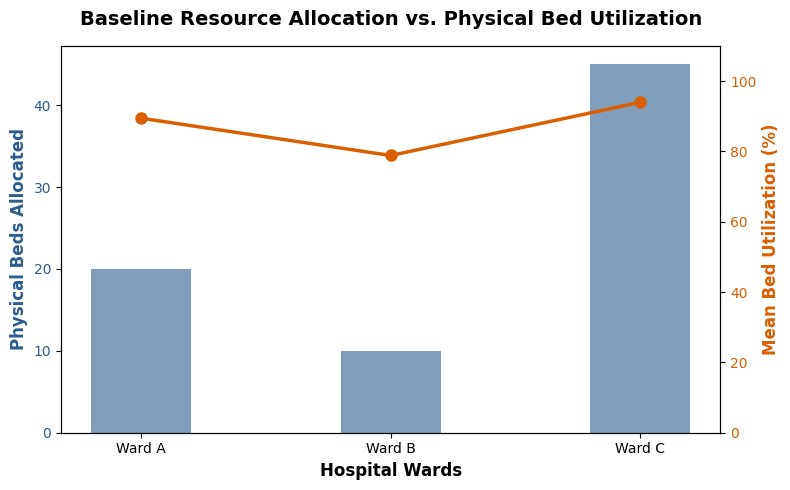

In [9]:
wards = ['Ward A', 'Ward B', 'Ward C']
beds_allocated = [20, 10, 45]
utilization = [89.44, 78.82, 93.96]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Bed Allocation as Bars
color = '#2b5c8f'
ax1.set_xlabel('Hospital Wards', fontsize=12, fontweight='bold')
ax1.set_ylabel('Physical Beds Allocated', color=color, fontsize=12, fontweight='bold')
bars = ax1.bar(wards, beds_allocated, color=color, alpha=0.6, width=0.4, label='Beds Allocated')
ax1.tick_params(axis='y', labelcolor=color)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()  
color = '#d95f02'
ax2.set_ylabel('Mean Bed Utilization (%)', color=color, fontsize=12, fontweight='bold')
line = ax2.plot(wards, utilization, color=color, marker='o', linewidth=2.5, markersize=8, label='Utilization %')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 110)

plt.title('Baseline Resource Allocation vs. Physical Bed Utilization', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

Sensitivity Analysis

Informed Grid Search from the original baseline showed that Ward B having 10 beds was over-allocated, ands Wards A and C did not have enough capacity, resulting in a high count of relocated/lost patients. Goal is to find the configuration of bed allocations that will result in the lowest sum of the relocated patients

With that:
- Ward B should have 3-8 beds; test it in a grid search

In [10]:
def run_informed_grid_search(total_beds=75, replications=3, use_exponential=False):

    best_total_relocations = float('inf')
    best_config = None
    results_list = []
    
    print(f"Starting Grid Search for Total Beds = {total_beds}...")
    print(f"Running {replications} replications per valid combination...\n")
    
    # Informed bounds based on baseline failure analysis
    # Ward B is kept lean; Ward A and C are given room to expand
    for b_B in range(2, 8):  
        for b_A in range(25, total_beds - b_B):
            b_C = total_beds - b_A - b_B
            
            # Guardrail: Ensure Ward C stays within a reasonable operating size
            if b_C < 25 or b_C > 55:
                continue

            print("Current Configuration -> Ward A:", b_A, "| Ward B:", b_B, "| Ward C:", b_C)
                
            # Run multi-replication simulation for this configuration
            total_relocations_this_config = 0
            
            for _ in range(replications):
                metrics = simulate_hospital(b_A, b_B, b_C, use_exponential_los=use_exponential)
                
                # Sum the relocations over all three patient types
                total_relocations_this_config += (
                    metrics['relocated_count']['regular'] +
                    metrics['relocated_count']['intensive'] +
                    metrics['relocated_count']['other']
                )
            
            # Calculate the statistical mean for this grid coordinate
            mean_relocations = total_relocations_this_config / replications
            print("Mean Relocations for Current Configuration:", mean_relocations)

            # Save data point for report plotting
            results_list.append({'Ward_A': b_A, 'Ward_B': b_B, 'Ward_C': b_C, 'Mean_Relocations': mean_relocations})
            
            # Check if this is our new global minimum
            if mean_relocations < best_total_relocations:
                print("New Optimal Configuration Found!")
                best_total_relocations = mean_relocations
                best_config = (b_A, b_B, b_C)
            
            print(" ")
                
    # Format into a clean DataFrame for easy analysis
    df_results = pd.DataFrame(results_list)
    
    print("=" * 60)
    print("                 GRID SEARCH OPTIMIZATION RESULTS               ")
    print("=" * 60)
    print(f" OPTIMAL BED DISTRIBUTION: Ward A = {best_config[0]} | Ward B = {best_config[1]} | Ward C = {best_config[2]}")
    print(f" MINIMUM EXPECTED ANNUAL RELOCATIONS: {best_total_relocations:.1f} patients / year")
    print(f" Baseline was ~2239.6. Net Patient Savings: {2239.6 - best_total_relocations:.1f} lives/year.")
    print("=" * 60)
    
    return df_results, best_config

In [11]:
# Execute Grid Search

df_exp, _ = run_informed_grid_search(total_beds=75, replications=5, use_exponential=True)
df_log, _ = run_informed_grid_search(total_beds=75, replications=5, use_exponential=False)

Starting Grid Search for Total Beds = 75...
Running 5 replications per valid combination...

Current Configuration -> Ward A: 25 | Ward B: 2 | Ward C: 48
Mean Relocations for Current Configuration: 2164.2
New Optimal Configuration Found!
 
Current Configuration -> Ward A: 26 | Ward B: 2 | Ward C: 47
Mean Relocations for Current Configuration: 2172.4
 
Current Configuration -> Ward A: 27 | Ward B: 2 | Ward C: 46
Mean Relocations for Current Configuration: 2163.2
New Optimal Configuration Found!
 
Current Configuration -> Ward A: 28 | Ward B: 2 | Ward C: 45
Mean Relocations for Current Configuration: 2139.2
New Optimal Configuration Found!
 
Current Configuration -> Ward A: 29 | Ward B: 2 | Ward C: 44
Mean Relocations for Current Configuration: 2162.2
 
Current Configuration -> Ward A: 30 | Ward B: 2 | Ward C: 43
Mean Relocations for Current Configuration: 2127.6
New Optimal Configuration Found!
 
Current Configuration -> Ward A: 31 | Ward B: 2 | Ward C: 42
Mean Relocations for Current C

In [12]:
df_exp.sort_values(by='Mean_Relocations', ascending=True).head(5)

,Ward_A,Ward_B,Ward_C,Mean_Relocations
37,38,3,34,2090.4
96,31,6,38,2118.6
128,43,7,25,2122.0
28,29,3,43,2122.0
26,27,3,45,2124.8


In [13]:
df_log.sort_values(by='Mean_Relocations', ascending=True).head(5)

# Notes:
# Exponential model thinks it needs 4 beds in Ward B because it expects smooth, predictable transitions. 
# But the Log-Normal model realizes that because of heavy-tailed stay variance, an extra bed inside a strict 4-wall ICU is easily wasted. 

,Ward_A,Ward_B,Ward_C,Mean_Relocations
50,28,4,43,2080.4
57,35,4,36,2082.4
63,41,4,30,2104.0
90,25,6,44,2105.2
14,39,2,34,2105.8


In [14]:
for index, row in df_log.sort_values(by='Mean_Relocations', ascending=True).iloc[:5, :3].iterrows():
    print(f"Configuration {index + 1}: Ward A = {row['Ward_A']}, Ward B = {row['Ward_B']}, Ward C = {row['Ward_C']}")
    evaluate_hospital_performance(row['Ward_A'], row['Ward_B'], row['Ward_C'], replications=100, use_exponential=False)

# Best found configuration: Ward A=34 | Ward B=3 | Ward C=38

Configuration 51: Ward A = 28, Ward B = 4, Ward C = 43

--- Performance Evaluation Summary (Log-Normal LOS) ---
Configuration: Ward A = 28 | Ward B = 4 | Ward C = 43 (100 replications)

Probability of blocking on arrival:
  Regular Care:   57.85%
  Intensive Care: 76.10%
  Other In-pat:   30.50%

Mean annual patient relocations:
  Regular Care:   1284.8 / year
  Intensive Care: 208.5 / year
  Other In-pat:   668.6 / year
  Total System:   2161.9 ± 16.5 / year (95% CI)

Mean bed utilization:
  Ward A: 87.47%
  Ward B: 86.08%
  Ward C: 94.29%
--------------------------------------------------

Configuration 58: Ward A = 35, Ward B = 4, Ward C = 36

--- Performance Evaluation Summary (Log-Normal LOS) ---
Configuration: Ward A = 35 | Ward B = 4 | Ward C = 36 (100 replications)

Probability of blocking on arrival:
  Regular Care:   48.88%
  Intensive Care: 75.91%
  Other In-pat:   41.01%

Mean annual patient relocations:
  Regular Care:   1084.6 / year
  Intensive Care: 178.3 / year
  Other

Simulation on having 70, 80 or 100 beds

In [15]:
def optimize_bed_distribution(total_beds, replications=3, use_exponential=False):
    """
    Finds the optimal allocation of beds across wards A, B, and C 
    to minimize total annual patient relocations.
    """
    min_relocations = float('inf')
    best_allocation = None
    records = []
    
    print(f"Running grid search for {total_beds} total beds ({replications} replications)...")
    
    # Bound Ward B between 2 and 7 to utilize the overflow rule efficiently
    for beds_B in range(2, 8):  
        
        # Calculate valid boundaries for Ward A based on 25 <= Ward C <= 55
        lower_bound_A = max(25, total_beds - beds_B - 55)
        upper_bound_A = total_beds - beds_B - 25
        
        if lower_bound_A > upper_bound_A:
            continue
            
        for beds_A in range(lower_bound_A, upper_bound_A + 1):
            beds_C = total_beds - beds_A - beds_B
            
            annual_relocations = 0
            for _ in range(replications):
                res = simulate_hospital(beds_A, beds_B, beds_C, use_exponential_los=use_exponential)
                annual_relocations += (
                    res['relocated_count']['regular'] +
                    res['relocated_count']['intensive'] +
                    res['relocated_count']['other']
                )
            
            mean_relocations = annual_relocations / replications
            records.append({
                'Ward_A': beds_A, 
                'Ward_B': beds_B, 
                'Ward_C': beds_C, 
                'Mean_Relocations': mean_relocations
            })
            
            if mean_relocations < min_relocations:
                min_relocations = mean_relocations
                best_allocation = (beds_A, beds_B, beds_C)
                
    if not best_allocation:
        print("Error: No valid allocations found within the specified capacity constraints.")
        return pd.DataFrame(), None

    print(f"\n--- Optimization Complete ({total_beds} Beds) ---")
    print(f"Optimal Allocation: Ward A = {best_allocation[0]}, Ward B = {best_allocation[1]}, Ward C = {best_allocation[2]}")
    print(f"Minimized Relocations: {min_relocations:.1f} per year\n")
    
    return pd.DataFrame(records), best_allocation

In [16]:
# Execute the scaling sweep effortlessly using the optimized engine
for capacity in [60, 80, 100]:
    # Phase 1 screening: 3 replications is perfect to find the coordinates
    _, best_layout = optimize_bed_distribution(total_beds=capacity, replications=3, use_exponential=False)

    if best_layout:
        print(f"Optimal allocation path for {capacity} beds: {best_layout}\n")

Running grid search for 60 total beds (3 replications)...

--- Optimization Complete (60 Beds) ---
Optimal Allocation: Ward A = 27, Ward B = 3, Ward C = 30
Minimized Relocations: 2620.0 per year

Optimal allocation path for 60 beds: (27, 3, 30)

Running grid search for 80 total beds (3 replications)...

--- Optimization Complete (80 Beds) ---
Optimal Allocation: Ward A = 26, Ward B = 4, Ward C = 50
Minimized Relocations: 1895.3 per year

Optimal allocation path for 80 beds: (26, 4, 50)

Running grid search for 100 total beds (3 replications)...

--- Optimization Complete (100 Beds) ---
Optimal Allocation: Ward A = 46, Ward B = 5, Ward C = 49
Minimized Relocations: 1265.3 per year

Optimal allocation path for 100 beds: (46, 5, 49)

